In [48]:
import pandas as pd

In [49]:
pd.__version__

'2.3.3'

# Country Economy Analysis using Pandas

## Objective
This project analyzes country-level data such as birth rate, internet usage, and income group using Pandas, Matplotlib, and Seaborn.

## Dataset
The dataset contains:
- CountryName
- CountryCode
- BirthRate
- InternetUsers
- IncomeGroup

## Steps Performed
1. Loaded the dataset
2. Checked data types and null values
3. Explored rows, columns, and shape
4. Performed slicing and descriptive statistics
5. Built visualizations to identify patterns

## Key Insights
- Internet usage varies widely across countries
- Birth rate tends to differ across income groups
- Higher-income groups often show greater internet penetration

In [50]:
from pathlib import Path

def _resolve_data_path() -> Path:
    """Find data file whether notebook runs from repo root or notebooks/."""
    candidates = [
        Path('data') / 'data.csv',
        Path('..') / 'data' / 'data.csv',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Could not find data.csv. Expected at data/data.csv (repo root)"
        " or ../data/data.csv (if running from notebooks/)."
    )

DATA_PATH = _resolve_data_path()
df = pd.read_csv(DATA_PATH)
DATA_PATH

In [51]:
df

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income
...,...,...,...,...,...
190,"Yemen, Rep.",YEM,32.947,20.0,Lower middle income
191,South Africa,ZAF,20.850,46.5,Upper middle income
192,"Congo, Dem. Rep.",COD,42.394,2.2,Low income
193,Zambia,ZMB,40.471,15.4,Lower middle income


In [52]:
type(df)

pandas.core.frame.DataFrame

In [53]:
len(df)

195

In [54]:
df.columns

Index(['CountryName', 'CountryCode', 'BirthRate', 'InternetUsers',
       'IncomeGroup'],
      dtype='object')

In [55]:
len(df.columns)

5

In [56]:
df.shape #dimension of the table

(195, 5)

In [57]:
df.isnull()

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
190,False,False,False,False,False
191,False,False,False,False,False
192,False,False,False,False,False
193,False,False,False,False,False


In [58]:
df.isnull().sum()

CountryName      0
CountryCode      0
BirthRate        0
InternetUsers    0
IncomeGroup      0
dtype: int64

In [59]:
df.head()#by default it gives top 5 rows and columns

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income


In [60]:
df.head(8)#if u specify any argumnet then u will get that desired rows and columns

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income
5,Argentina,ARG,17.716,59.9,High income
6,Armenia,ARM,13.308,41.9,Lower middle income
7,Antigua and Barbuda,ATG,16.447,63.4,High income


In [61]:
df.tail()# bottom 5 rows and columns

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
190,"Yemen, Rep.",YEM,32.947,20.0,Lower middle income
191,South Africa,ZAF,20.850,46.5,Upper middle income
192,"Congo, Dem. Rep.",COD,42.394,2.2,Low income
193,Zambia,ZMB,40.471,15.4,Lower middle income
194,Zimbabwe,ZWE,35.715,18.5,Low income


In [62]:
df.dtypes

CountryName       object
CountryCode       object
BirthRate        float64
InternetUsers    float64
IncomeGroup       object
dtype: object

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryName    195 non-null    object 
 1   CountryCode    195 non-null    object 
 2   BirthRate      195 non-null    float64
 3   InternetUsers  195 non-null    float64
 4   IncomeGroup    195 non-null    object 
dtypes: float64(2), object(3)
memory usage: 7.7+ KB


slicing in Pandas

In [64]:
df[::]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income
...,...,...,...,...,...
190,"Yemen, Rep.",YEM,32.947,20.0,Lower middle income
191,South Africa,ZAF,20.850,46.5,Upper middle income
192,"Congo, Dem. Rep.",COD,42.394,2.2,Low income
193,Zambia,ZMB,40.471,15.4,Lower middle income


In [65]:
df[0:50:5]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.90,High income
5,Argentina,ARG,17.716,59.90,High income
10,Azerbaijan,AZE,18.300,58.70,Upper middle income
15,Bangladesh,BGD,20.142,6.63,Lower middle income
20,Belarus,BLR,12.500,54.17,Upper middle income
25,Barbados,BRB,12.188,73.00,High income
30,Canada,CAN,10.900,85.80,High income
35,Cameroon,CMR,37.236,6.40,Lower middle income
40,Costa Rica,CRI,15.022,45.96,Upper middle income
45,Germany,DEU,8.500,84.17,High income


In [66]:
df[:5]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income


In [67]:
df[::10]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.900000,High income
10,Azerbaijan,AZE,18.300,58.700000,Upper middle income
20,Belarus,BLR,12.500,54.170000,Upper middle income
30,Canada,CAN,10.900,85.800000,High income
40,Costa Rica,CRI,15.022,45.960000,Upper middle income
50,Ecuador,ECU,21.070,40.353684,Upper middle income
60,Gabon,GAB,30.555,9.200000,Upper middle income
70,Greenland,GRL,14.500,65.800000,High income
80,India,IND,20.291,15.100000,Lower middle income
90,Kazakhstan,KAZ,22.730,54.000000,Upper middle income


In [68]:
df[::-10]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
194,Zimbabwe,ZWE,35.715,18.5000,Low income
184,"Venezuela, RB",VEN,19.842,54.9000,High income
174,Trinidad and Tobago,TTO,14.590,63.8000,High income
164,Swaziland,SWZ,30.093,24.7000,Lower middle income
154,Sierra Leone,SLE,36.729,1.7000,Low income
144,French Polynesia,PYF,16.393,56.8000,High income
134,Oman,OMN,20.419,66.4500,High income
124,Malaysia,MYS,16.805,66.9700,Upper middle income
114,"Macedonia, FYR",MKD,11.222,65.2400,Upper middle income
104,Lesotho,LSO,28.738,5.0000,Lower middle income


In [69]:
df[::-1]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
194,Zimbabwe,ZWE,35.715,18.5,Low income
193,Zambia,ZMB,40.471,15.4,Lower middle income
192,"Congo, Dem. Rep.",COD,42.394,2.2,Low income
191,South Africa,ZAF,20.850,46.5,Upper middle income
190,"Yemen, Rep.",YEM,32.947,20.0,Lower middle income
...,...,...,...,...,...
4,United Arab Emirates,ARE,11.044,88.0,High income
3,Albania,ALB,12.877,57.2,Upper middle income
2,Angola,AGO,45.985,19.1,Upper middle income
1,Afghanistan,AFG,35.253,5.9,Low income


.describe()---descriptive stats

In [70]:
df.describe()#it will read only numerical attributes

,BirthRate,InternetUsers
count,195.000000,195.000000
mean,21.469928,42.076471
std,10.605467,29.030788
min,7.900000,0.900000
25%,12.120500,14.520000
50%,19.680000,41.000000
75%,29.759500,66.225000
max,49.661000,96.546800


In [71]:
df_cat=df[['CountryName',	'CountryCode','IncomeGroup']]
df_cat.head(6)


,CountryName,CountryCode,IncomeGroup
0,Aruba,ABW,High income
1,Afghanistan,AFG,Low income
2,Angola,AGO,Upper middle income
3,Albania,ALB,Upper middle income
4,United Arab Emirates,ARE,High income
5,Argentina,ARG,High income


In [72]:
df_num = df[['BirthRate','InternetUsers']]
df_num

,BirthRate,InternetUsers
0,10.244,78.9
1,35.253,5.9
2,45.985,19.1
3,12.877,57.2
4,11.044,88.0
...,...,...
190,32.947,20.0
191,20.850,46.5
192,42.394,2.2
193,40.471,15.4


In [73]:
print(df.shape)
print(df_num.shape)
print(df_cat.shape)

(195, 5)
(195, 2)
(195, 3)


In [74]:
print(df.columns)
print(df_num.columns)
print(df_cat.columns)

Index(['CountryName', 'CountryCode', 'BirthRate', 'InternetUsers',
       'IncomeGroup'],
      dtype='object')
Index(['BirthRate', 'InternetUsers'], dtype='object')
Index(['CountryName', 'CountryCode', 'IncomeGroup'], dtype='object')


In [75]:
df_cat.describe()

,CountryName,CountryCode,IncomeGroup
count,195,195,195
unique,195,195,4
top,Aruba,ABW,High income
freq,1,1,67


In [76]:
df_cat.describe().T      #T refers to Transpose

,count,unique,top,freq
CountryName,195,195,Aruba,1
CountryCode,195,195,ABW,1
IncomeGroup,195,4,High income,67


In [77]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
BirthRate,195.0,21.469928,10.605467,7.9,12.1205,19.68,29.7595,49.6610
InternetUsers,195.0,42.076471,29.030788,0.9,14.5200,41.00,66.2250,96.5468


In [78]:
df.columns=['a','b','c','d','e']
df.head(4)

,a,b,c,d,e
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income


In [87]:
df.columns = ['CountryName', 'CountryCode', 'BirthRate', 'InternetUsers',
       'IncomeGroup']
df.head(7)

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income
5,Argentina,ARG,17.716,59.9,High income
6,Armenia,ARM,13.308,41.9,Lower middle income


In [80]:
df['InternetUsers']<2

,InternetUsers
0,False
1,False
2,False
3,False
4,False
...,...
190,False
191,False
192,False
193,False


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (CountryName,)    195 non-null    object 
 1   (CountryCode,)    195 non-null    object 
 2   (BirthRate,)      195 non-null    float64
 3   (InternetUsers,)  195 non-null    float64
 4   (IncomeGroup,)    195 non-null    object 
dtypes: float64(2), object(3)
memory usage: 7.7+ KB


In [90]:
df[df['InternetUsers'] < 2]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
11,Burundi,BDI,44.151,1.3,Low income
52,Eritrea,ERI,34.800,0.9,Low income
55,Ethiopia,ETH,32.925,1.9,Low income
64,Guinea,GIN,37.337,1.6,Low income
117,Myanmar,MMR,18.119,1.6,Lower middle income
127,Niger,NER,49.661,1.7,Low income
154,Sierra Leone,SLE,36.729,1.7,Low income
156,Somalia,SOM,43.891,1.5,Low income
172,Timor-Leste,TLS,35.755,1.1,Lower middle income


In [91]:
len(df[df['InternetUsers']<2])

9

In [94]:
df

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income
...,...,...,...,...,...
190,"Yemen, Rep.",YEM,32.947,20.0,Lower middle income
191,South Africa,ZAF,20.850,46.5,Upper middle income
192,"Congo, Dem. Rep.",COD,42.394,2.2,Low income
193,Zambia,ZMB,40.471,15.4,Lower middle income


In [93]:
df['BirthRate']>40

0      False
1      False
2       True
3      False
4      False
       ...  
190    False
191    False
192     True
193     True
194    False
Name: BirthRate, Length: 195, dtype: bool

In [95]:
len(df['BirthRate']>40)

195

In [96]:
df[df['BirthRate']>40]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
2,Angola,AGO,45.985,19.1,Upper middle income
11,Burundi,BDI,44.151,1.3,Low income
14,Burkina Faso,BFA,40.551,9.1,Low income
65,"Gambia, The",GMB,42.525,14.0,Low income
115,Mali,MLI,44.138,3.5,Low income
127,Niger,NER,49.661,1.7,Low income
128,Nigeria,NGA,40.045,38.0,Lower middle income
156,Somalia,SOM,43.891,1.5,Low income
167,Chad,TCD,45.745,2.3,Low income
178,Uganda,UGA,43.474,16.2,Low income


In [102]:
df[(df.BirthRate > 40)& (df.InternetUsers<2)]

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
11,Burundi,BDI,44.151,1.3,Low income
127,Niger,NER,49.661,1.7,Low income
156,Somalia,SOM,43.891,1.5,Low income


In [103]:
df.head()

,CountryName,CountryCode,BirthRate,InternetUsers,IncomeGroup
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income


In [104]:
 df['IncomeGroup'].unique()

array(['High income', 'Low income', 'Upper middle income',
       'Lower middle income'], dtype=object)

In [105]:
  df['IncomeGroup'].nunique()# nunique gives you the num of unique values

4

Visualization

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns# adv visualization

In [107]:
%matplotlib inline
plt.rcParams['figure.figsize']= (6,2)

In [108]:
import warnings
warnings.filterwarnings('ignore')

In [112]:
df['InternetUsers']

0      78.9
1       5.9
2      19.1
3      57.2
4      88.0
       ... 
190    20.0
191    46.5
192     2.2
193    15.4
194    18.5
Name: InternetUsers, Length: 195, dtype: float64

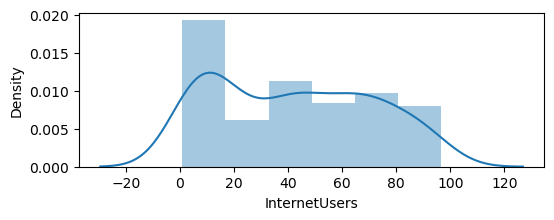

In [113]:
vis1 = sns.distplot(df['InternetUsers'])

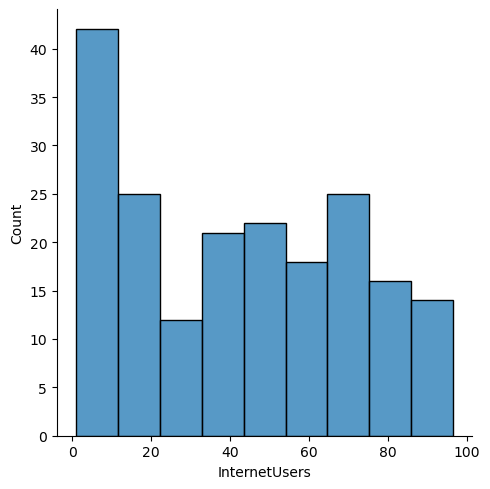

In [115]:
vis2 = sns.displot(df['InternetUsers'])

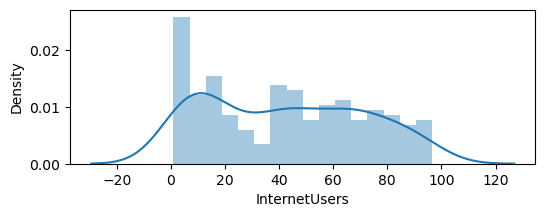

In [119]:
vis3 = sns.distplot(df['InternetUsers'],bins = 16)

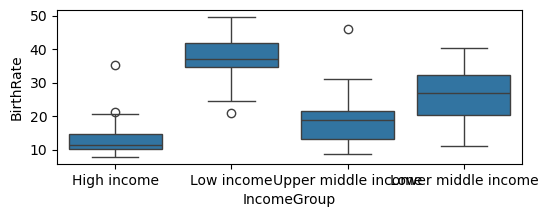

In [123]:
vis4 = sns.boxplot(data = df, x="IncomeGroup", y="BirthRate")

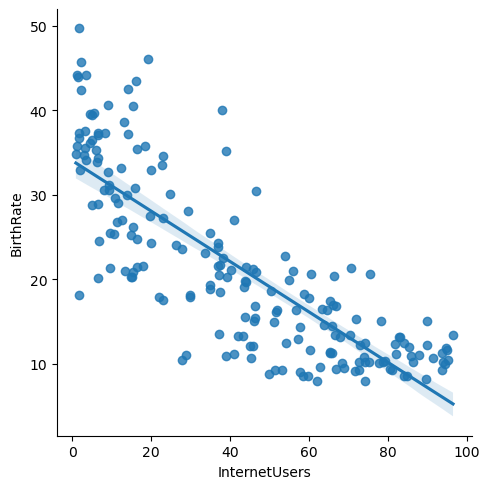

In [124]:
vis5 = sns.lmplot(data = df, x = 'InternetUsers', y = 'BirthRate')

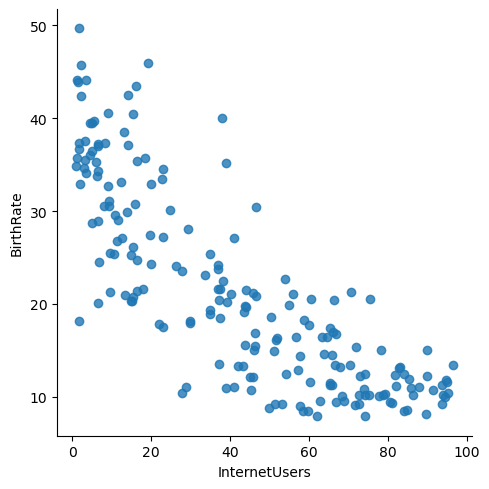

In [128]:
 vis6 = sns.lmplot(data = df, x = 'InternetUsers', y = 'BirthRate',fit_reg = False)

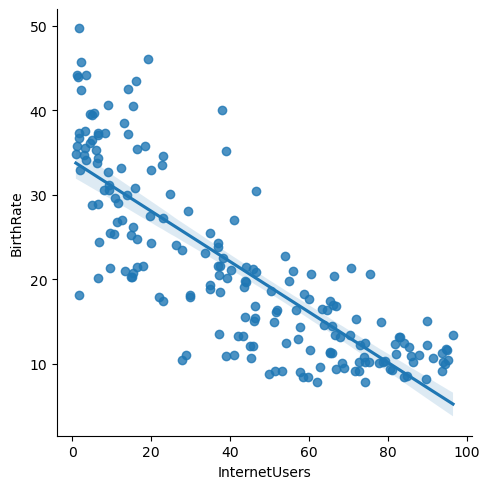

In [129]:
  vis7= sns.lmplot(data = df, x = 'InternetUsers', y = 'BirthRate',fit_reg = True)

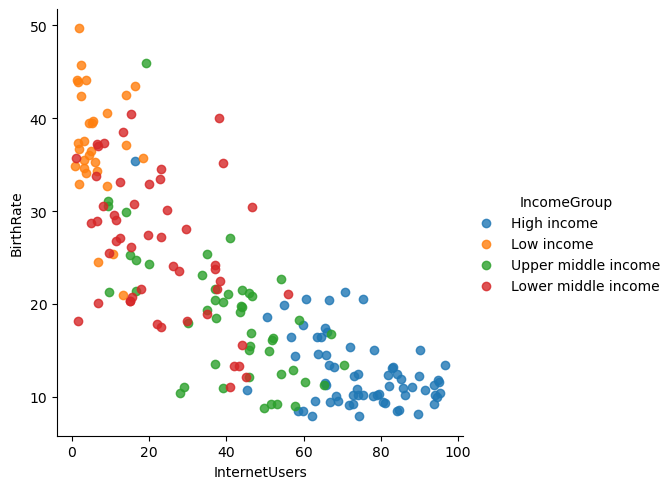

In [130]:
 vis8 = sns.lmplot(data = df, x = 'InternetUsers', y = 'BirthRate',fit_reg = False,hue='IncomeGroup')

In [ ]:
# Phase 2 additions: Practical, recruiter-friendly analysis
# (Run these cells after the dataset loads.)

## Data quality checks (missing values, duplicates, types)

Goal: quickly validate the dataset is usable for analysis and highlight any assumptions.

In [ ]:
expected_columns = ['CountryName', 'CountryCode', 'BirthRate', 'InternetUsers', 'IncomeGroup']
missing_cols = sorted(set(expected_columns) - set(df.columns))
extra_cols = sorted(set(df.columns) - set(expected_columns))

print('Missing columns:', missing_cols)
print('Extra columns:', extra_cols)

missing_values = df.isna().sum().sort_values(ascending=False)
print('\nMissing values (top):')
display(missing_values.head(10))

dup_rows = int(df.duplicated().sum())
dup_country_code = int(df.duplicated(subset=['CountryCode']).sum())
print(f"\nDuplicate rows: {dup_rows}")
print(f"Duplicate CountryCode values: {dup_country_code}")

df.dtypes

**Business insights (data quality)**
- If duplicates exist (especially by `CountryCode`), results like “top 10 countries” can be misleading.
- If numeric columns contain missing values, group comparisons (e.g., by income group) should report sample sizes.
- Confirming expected columns/types early makes the analysis repeatable and easier to extend later.

## Grouped analysis by IncomeGroup

Summarize typical birth rates and internet usage by income group.

In [ ]:
group_summary = (
    df.groupby('IncomeGroup')
      .agg(
          countries=('CountryCode', 'nunique'),
          birthrate_median=('BirthRate', 'median'),
          birthrate_iqr=('BirthRate', lambda s: s.quantile(0.75) - s.quantile(0.25)),
          internet_median=('InternetUsers', 'median'),
          internet_iqr=('InternetUsers', lambda s: s.quantile(0.75) - s.quantile(0.25)),
      )
      .sort_values('internet_median', ascending=False)
)
group_summary

**Business insights (income groups)**
- Income group helps explain “typical” internet penetration levels; medians are more robust than averages for skewed distributions.
- Birth rate differences by income group can help segment countries for policy or market-entry analysis.
- The IQR (spread) highlights whether a group is consistent or has wide variation (which matters for targeting).

## Ranked country comparisons

Identify countries at the extremes (highest/lowest internet usage; highest birth rates).

In [ ]:
top_internet = df.sort_values('InternetUsers', ascending=False).head(10)[
    ['CountryName', 'IncomeGroup', 'InternetUsers']
]
bottom_internet = df.sort_values('InternetUsers', ascending=True).head(10)[
    ['CountryName', 'IncomeGroup', 'InternetUsers']
]
top_birthrate = df.sort_values('BirthRate', ascending=False).head(10)[
    ['CountryName', 'IncomeGroup', 'BirthRate']
]

display(top_internet)
display(bottom_internet)
display(top_birthrate)

**Business insights (rankings)**
- Extremes are useful for storytelling: they quickly show where access is near-universal vs. limited.
- Comparing extremes *within* the same income group can reveal outliers worth investigating (policy, geography, infrastructure).
- High birth-rate countries often indicate younger populations, which can influence education/healthcare demand forecasts.

## Correlation analysis

Quantify the relationship between internet usage and birth rate overall and by income group.

In [ ]:
overall_corr = df[['InternetUsers', 'BirthRate']].corr(method='pearson').iloc[0, 1]
corr_by_group = (
    df.groupby('IncomeGroup')[['InternetUsers', 'BirthRate']]
      .corr(method='pearson')
      .iloc[0::2, -1]
      .rename('pearson_corr')
      .reset_index()
      .rename(columns={'level_1': 'metric'})
      .drop(columns=['metric'])
      .sort_values('pearson_corr')
)

print('Overall Pearson correlation (InternetUsers vs BirthRate):', round(float(overall_corr), 3))
corr_by_group

**Business insights (correlation)**
- A negative correlation would support the idea that countries with higher internet access tend to have lower birth rates.
- Segmenting by income group prevents “apples-to-oranges” comparisons (income group is a major confounder).
- Correlation is not causation; this is best used as an EDA signal, not a policy conclusion.

## Cleaner charts (better labels + formatting)

Recreate core visuals with consistent sizing, titles, and axis labels.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

# Distribution of Internet Users
plt.figure(figsize=(9, 4))
sns.histplot(df['InternetUsers'], bins=20, kde=True, color='#2a6fbb')
plt.title('Distribution of Internet Users (%) Across Countries')
plt.xlabel('Internet Users (% of population)')
plt.ylabel('Number of countries')
plt.tight_layout()
plt.show()

# BirthRate by income group
plt.figure(figsize=(10, 4))
order = (
    df.groupby('IncomeGroup')['InternetUsers']
      .median()
      .sort_values(ascending=False)
      .index
)
sns.boxplot(data=df, x='IncomeGroup', y='BirthRate', order=order, palette='Set2')
plt.title('Birth Rate by Income Group')
plt.xlabel('Income group')
plt.ylabel('Birth rate')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# InternetUsers vs BirthRate (colored by income group)
g = sns.lmplot(
    data=df,
    x='InternetUsers',
    y='BirthRate',
    hue='IncomeGroup',
    height=5,
    aspect=1.4,
    scatter_kws={'alpha': 0.75, 's': 40},
    line_kws={'linewidth': 2},
)
g.set_axis_labels('Internet Users (% of population)', 'Birth rate')
plt.title('Internet Usage vs Birth Rate (by Income Group)')
plt.tight_layout()
plt.show()